# Schlafprobleme im Zusammenhang mit Lebensweise
### Datensatz:
**Sleep Health and Lifestyle Dataset**

## Ablauf

1. Datenüberblick
2. Datenbereinigung
3. Datenvisualisierung 
4. Train-Test-Split
5. Feature Engineering & Feature Selection
6. Modelierung
7. Auswertung

## 1. Datenüberblick

##### Importe

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


##### CSV-Datei einlesen und als pandas Dataframe speichern

In [44]:
df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In `df` ist jetzt also der Datensatz gespeichert. ("df" = **D**ata**f**rame)

`df.head()` zeigt die ersten 5 Spalten des Datensatzes an.

In [45]:
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


#### Beobachtungen

Der Überblick zeigt einige Auffälligkeiten:
- abgesehen von "Sleep Disorder" scheint es keine leeren Werte zu geben. Aus der Info des Datensatzes geht hervor, dass die leeren Werte für gesunde Menschen stehen -> das muss angepasst werden, damit es richtig visualisert und genutzt werden kann
- "Blood Pressure" hat den Datentyp "str" -> es sollte Integer sein

Im folgenden sollen die Features grob visualiert werden, um ein Gefühl für die Daten zu bekommen. Dies dient dazu, um die Datenbereingung effizient durchführen zu können und zuverlässig Unstimmigkeiten erkennen zu können. Die tatsächliche Datenvisualisierung kommt in einem späteren Schritt.

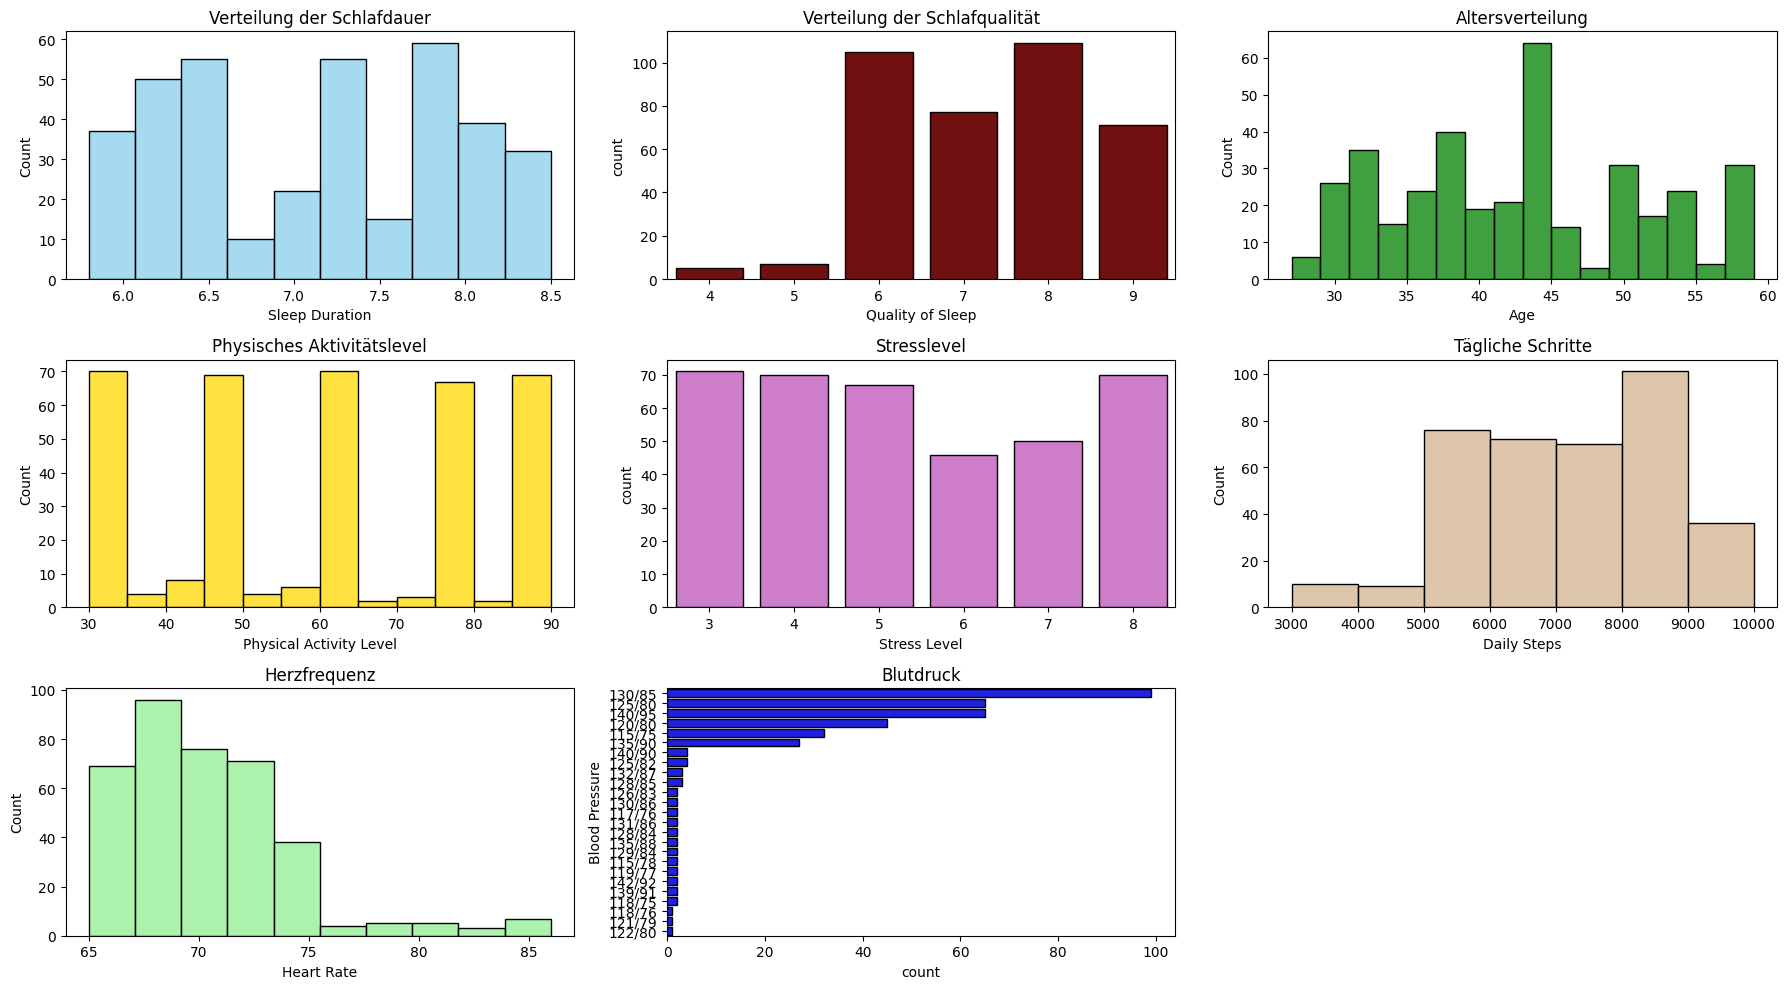

In [46]:
# Raster mit 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(3, 3, figsize=(18, 10))

# Schlafdauer
sns.histplot(df["Sleep Duration"], ax=axes[0, 0], color="skyblue",)
axes[0, 0].set_title("Verteilung der Schlafdauer")

# Schlafqualität
sns.countplot(df, x="Quality of Sleep", ax=axes[0, 1], color="maroon", edgecolor="black")
axes[0, 1].set_title("Verteilung der Schlafqualität")

# Alter
sns.histplot(df, x="Age", ax=axes[0, 2], color="green", binwidth=2)
axes[0, 2].set_title("Altersverteilung")

# Aktivitätslevel
sns.histplot(df, x = "Physical Activity Level", ax=axes[1, 0], color="gold", binwidth=5)
axes[1, 0].set_title("Physisches Aktivitätslevel")

# Stresslevel
sns.countplot(df,x="Stress Level", ax=axes[1, 1], color="orchid", edgecolor= "black")
axes[1, 1].set_title("Stresslevel")

# Schritte
sns.histplot(df,x="Daily Steps", ax=axes[1, 2], color="tan", binwidth=1000)
axes[1, 2].set_title("Tägliche Schritte")


sns.histplot(df,x="Heart Rate", ax=axes[2, 0], color="lightgreen", binwidth=2)
axes[2, 0].set_title("Herzfrequenz")

sns.countplot(
    data=df, 
    y='Blood Pressure', 
    ax=axes[2,1],
    order=df['Blood Pressure'].value_counts().index,
    color="blue",
    edgecolor='black'
)
axes[2, 1].set_title("Blutdruck")

axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

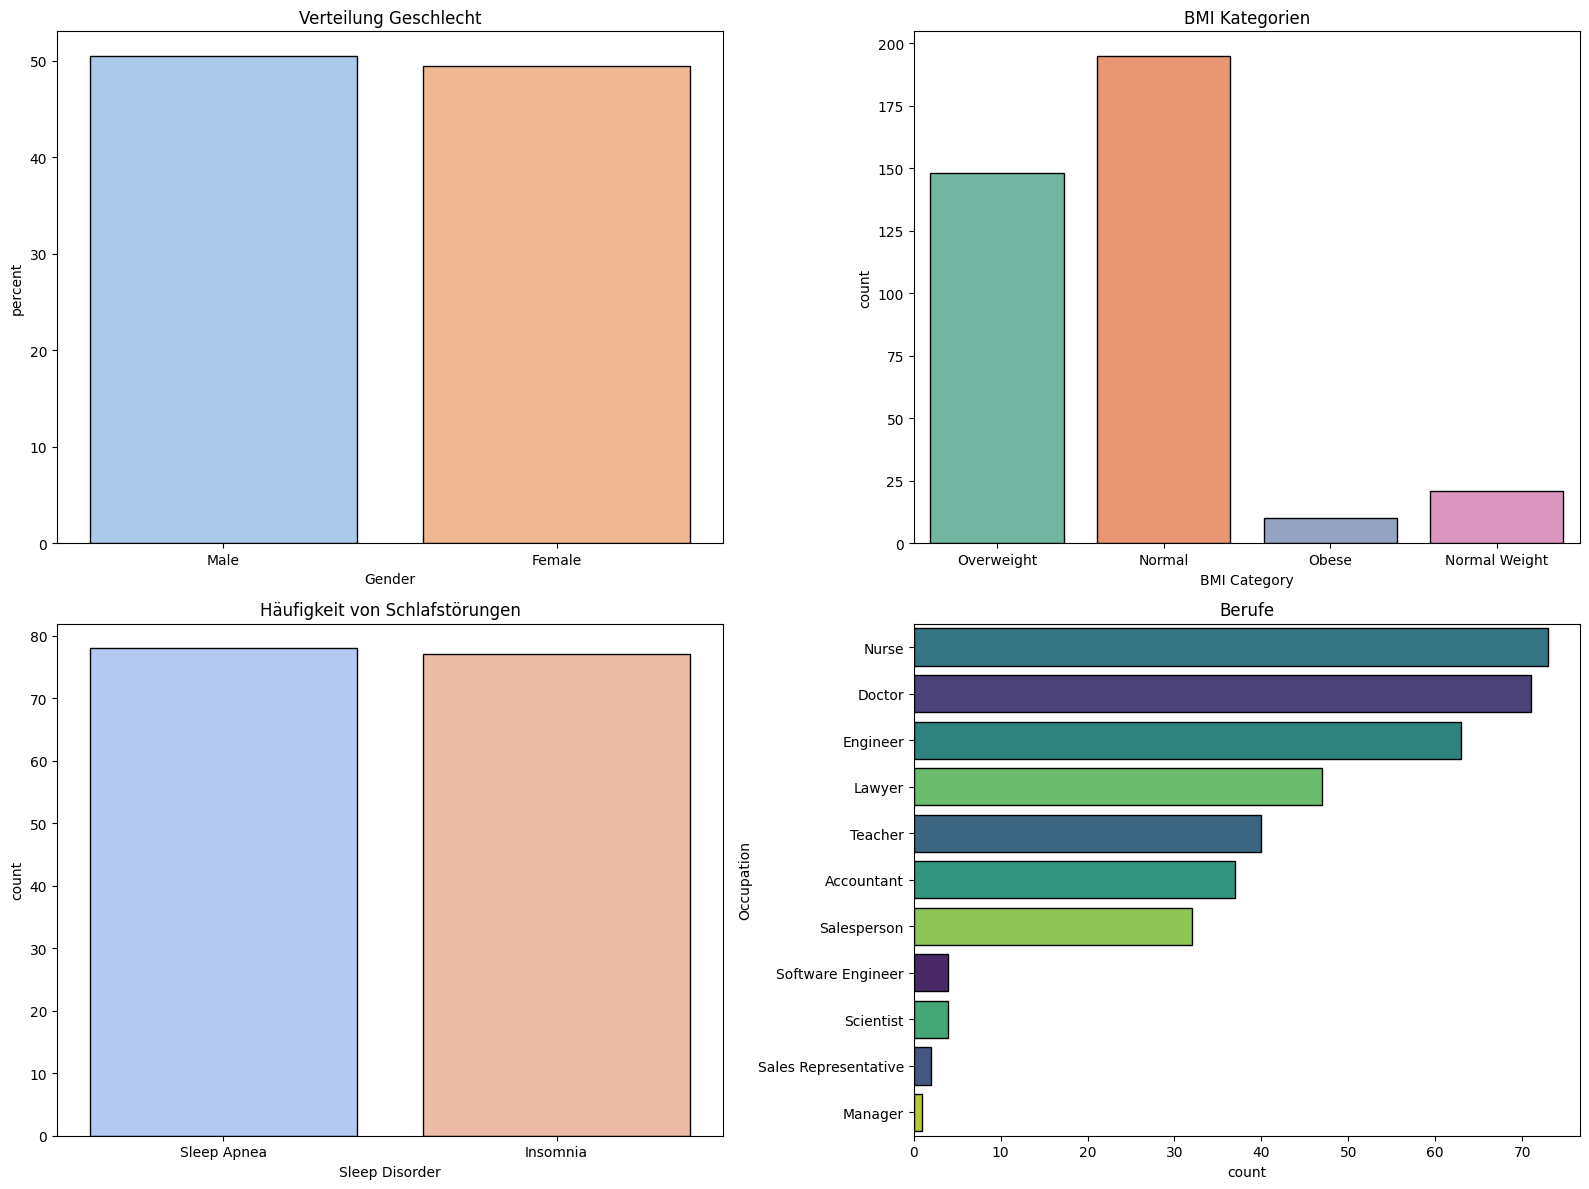

In [47]:


# Raster mit 2 Zeilen, 2 Spalten
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
sns.countplot(data=df, x='Gender', ax=axes[0, 0], palette='pastel', edgecolor='black', stat="percent", hue="Gender", legend=False)
axes[0, 0].set_title('Verteilung Geschlecht')

# BMI Category
sns.countplot(data=df, x='BMI Category', ax=axes[0, 1], palette='Set2', edgecolor='black', hue="BMI Category", legend=False)
axes[0, 1].set_title('BMI Kategorien')

# Sleep Disorder
sns.countplot(data=df, x='Sleep Disorder', ax=axes[1, 0], palette='coolwarm', edgecolor='black', hue="Sleep Disorder", legend=False)
axes[1, 0].set_title('Häufigkeit von Schlafstörungen')

# Occupation
sns.countplot(data=df, y='Occupation', ax=axes[1, 1], palette='viridis', edgecolor='black', order=df['Occupation'].value_counts().index, hue="Occupation", legend=False)
axes[1, 1].set_title('Berufe')

plt.tight_layout()
plt.show()

### Erste Auffälligkeiten
- männlicher und weiblicher Anteil ca. gleich verteilt
- In der Kategorie "Gewicht" ist "normal" doppelt vorhanden: "Normal" und "Normal Weight" -> bereinigen, bzw. gleiche Kategorien zusammenführen


In [48]:
df["BMI Category"].unique()

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

- Standardmäßig tauchen die Personen ohne Schlafstörung nicht im Schlafstörungsdiagramm auf -> Daten müssen so angepasst werden, dass sie nicht als "leer" interpretiert werden
- Der Blutdruck ist in dem aktuellen Format (z.B. 120/80) nicht gut geeignet. Man müsste den Wert in einen systolischen und einen diastolischen splitten, um damit arbeiten zu können und ihn richtig visualisieren zu können
- Die Verteilung der Physischen Atikität deutet darauf hin, dass es innerhalb dieser Kategorie Cluster gibt
- Daten wie "männlich" oder "weiblich" können vom Modell nicht verstanden werden und müssen encoded werden
- Die ID wird nicht benötigt, da die Daten ohnehin anonymisiert verarbeitet werden sollen und das Modell aus dem Feature "ID" keine Informationen ableiten kann -> Feature Selection

## 2. Datenbereinigung

C:\Users\lthom\AppData\Local\Temp\ipykernel_12424\3884599425.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='BMI Category', palette='Set2', edgecolor='black', stat='percent')


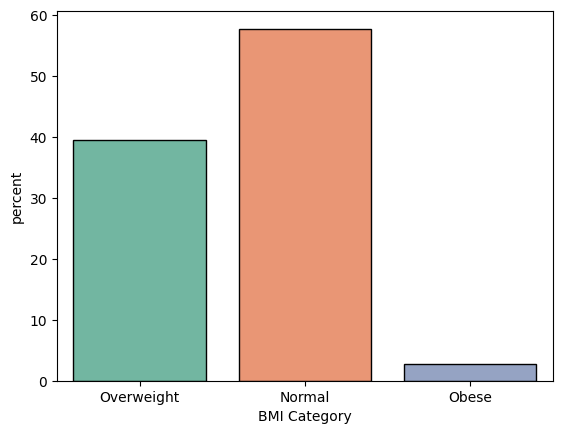

In [49]:
df_cleaned = df.copy()

df_cleaned['BMI Category'] = df_cleaned['BMI Category'].replace('Normal Weight', 'Normal')

# neu plotten
sns.countplot(data=df_cleaned, x='BMI Category', palette='Set2', edgecolor='black', stat='percent')

plt.show()


Wie man im Diagramm sehen kann, sind jetzt nur noch die drei Kategorien vorhanden. 

Außerdem wurde eine Kopie des Datensatzes erstellt, mit dem im weiteren gearbeitet wird.

Als nächstes wird der Wert für die gesunden Personen so verändert, dass sie im Diagramm auftauchen. 
Momentan sind die Werte für gesunde Personen, in der Kategorie "Sleep Disorer" NaN (Not a Number), da sie im ursprünglichen Datensatz "None" waren. 

Sie werden jetzt so ersetzt, dass der Wert "Healthy" heißt.
Davor wird noch einmal geprüft, welche Kategorien es gibt.

In [50]:
# prüfen, welche Kategorien es gibt
df_cleaned['Sleep Disorder'].unique()

<StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [51]:
df_cleaned['Sleep Disorder'] = df_cleaned['Sleep Disorder'].fillna('Healthy')

# erneute Prüfung
df_cleaned['Sleep Disorder'].unique()

<StringArray>
['Healthy', 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

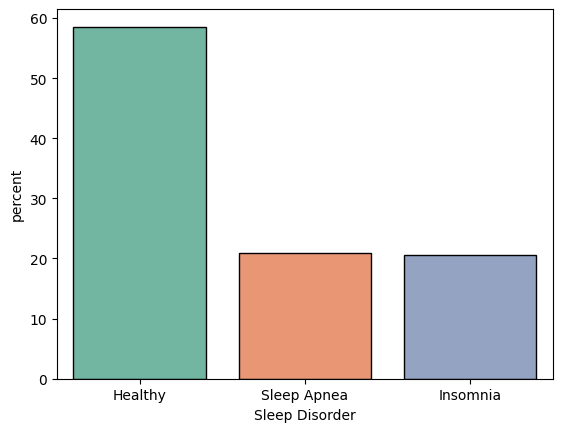

In [52]:
# neu plotten
sns.countplot(data=df_cleaned, x='Sleep Disorder', palette='Set2', edgecolor='black', stat='percent', hue="Sleep Disorder", legend=False)

plt.show()

Jetzt wollen wir, das Feature "Blutdruck" so bereinigen, dass damit gearbeitet werden kann. Dafür werden zwei neue Features erstellt, "Systolic" und "Diastolic", also der obere und untere Wert. Beide werden als strings gespeichert.
Zuletzt wird das alte Feature gelöscht, da es keinerlei neue Information bereitstellt.

In [53]:

# expand = True: sorgt dafür, dass die beiden Werte in neue Spalten geschrieben werden und nicht in eine als Liste ["120", "80"]
df_cleaned[['Systolic', 'Diastolic']] = df_cleaned['Blood Pressure'].str.split('/', expand=True)

# der aktuelle Datentyp
print(df_cleaned[['Systolic', 'Diastolic']].dtypes)

# da Datentyp: str -> Umwandeln in int
df_cleaned['Systolic'] = df_cleaned['Systolic'].astype(int)
df_cleaned['Diastolic'] = df_cleaned['Diastolic'].astype(int)

df_cleaned = df_cleaned.drop(columns=["Blood Pressure"])

df_cleaned.head()


Systolic     str
Diastolic    str
dtype: object


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## 3. Datenvisualisierung

Jetzt sollen die Daten mithilfe von geeigneten Diagrammen visualisiert werden. Es sollte dazu dienen um die genaue Struktur der Daten deutlich zu machen und hypothesenrelevante Muster sowie Korrelationen zu identifizieren, die als Grundlage für die spätere Modellierung dienen.

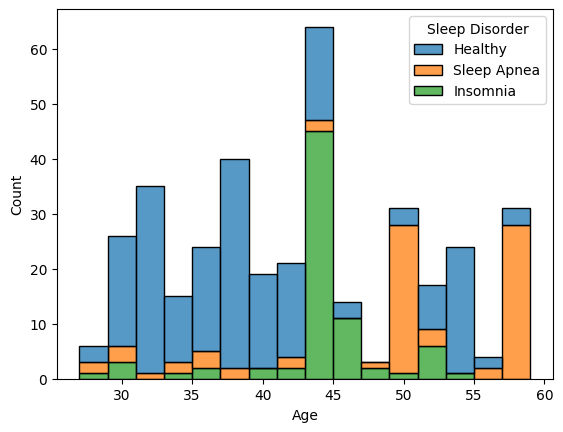

In [11]:
sns.histplot(data=df_cleaned, x='Age', hue='Sleep Disorder', multiple='stack', binwidth=2)
plt.show()

Das Diagramm zeigt, dass die Menschen im Alter von 43 bis 47 am häufigsten von Insomnie betroffen sind, während Schlafapnoe im höheren Alter vermehrt auftritt. Vor 40 treten die Schlafstörungen eher vereinzelt auf.

Weitere Zusammenhänge der Features soll durch die Korrelationsmatrix verdeutlicht werden.

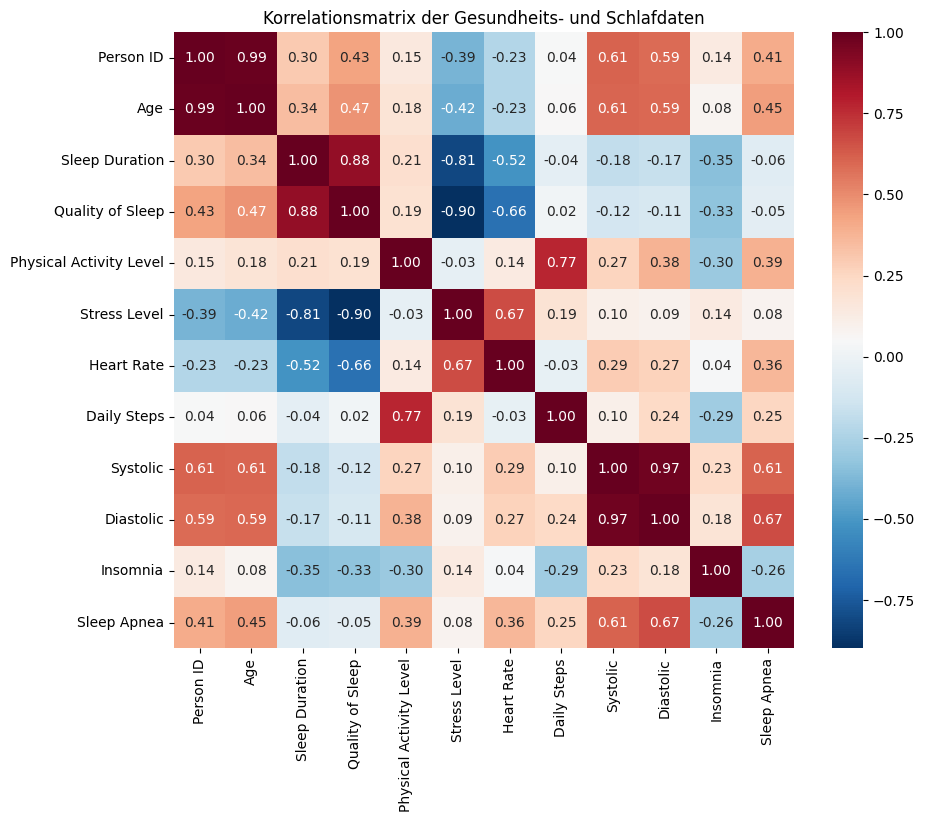

In [40]:
df_analysis = df_cleaned.copy()

# encoding der zielvariable für die visualisierung
disorder_dummies = pd.get_dummies(df_analysis['Sleep Disorder']).astype(int)
df_analysis[["Insomnia", "Sleep Apnea"]] = disorder_dummies[["Insomnia", "Sleep Apnea"]]
df_analysis.head()

plt.figure(figsize=(10, 8))
sns.heatmap(df_analysis.select_dtypes(include=['number']).corr(), 
            annot=True, cmap='RdBu_r', fmt='.2f')

plt.title('Korrelationsmatrix der Gesundheits- und Schlafdaten')
plt.show()

**Die wichtigsten Erkenntnisse aus der Matrix**

- das Stresslevel korreliert negativ mit sowohl der Schlafdauer als auch der Schlafqualität
- körperliche Aktivität und Schrittanzahl korrelieren stark positiv miteinander
- Der Blutdruck (Systolischer und Diastolischer Wert) korreliert mit dem Alter
- die Herzfrequenz und das Stresslevel korrelieren ebenfalls miteinander

**In Bezug auf die Zielvariablen:**

- das Alter scheint vor allem mit Schlafapnoe zusammenzuhängen, nicht jedoch mit Insomnie
- eine starke Korrelation besteht zwischen Schlafapnoe und dem Blutdruck, aber auch der Herzfrequenz
- das Stresslevel korreliert am wenigsten mit beiden Erkrankungen, obwohl es einen sehr starken Zusammenhang zur Schlafqualität gibt



**weitere Analyse**

Im folgenden sollen die Erkenntnisse aus der Korrelationsmatrix noch weiter untersucht werden.

C:\Users\lthom\AppData\Local\Temp\ipykernel_12424\2907730741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Stress Level', y='Quality of Sleep', palette='Reds')


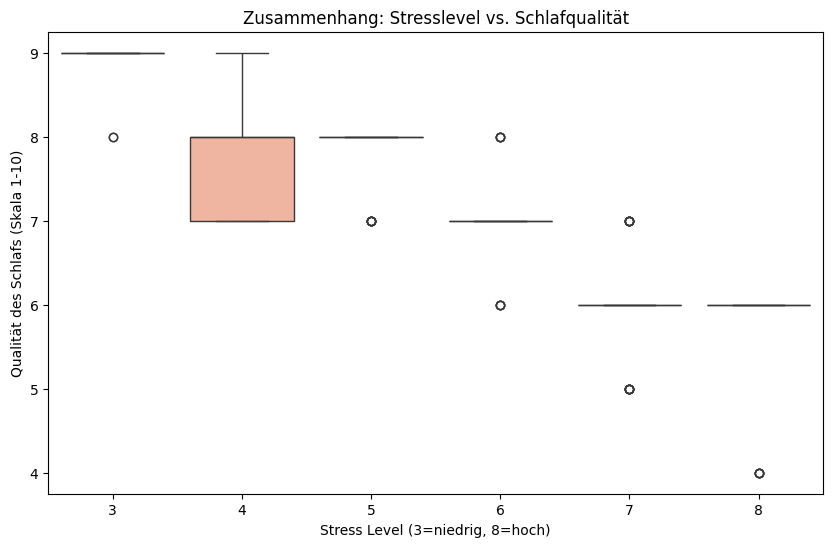

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='Stress Level', y='Quality of Sleep', palette='Reds')
plt.title('Zusammenhang: Stresslevel vs. Schlafqualität')
plt.xlabel('Stress Level (3=niedrig, 8=hoch)')
plt.ylabel('Qualität des Schlafs (Skala 1-10)')
plt.show()

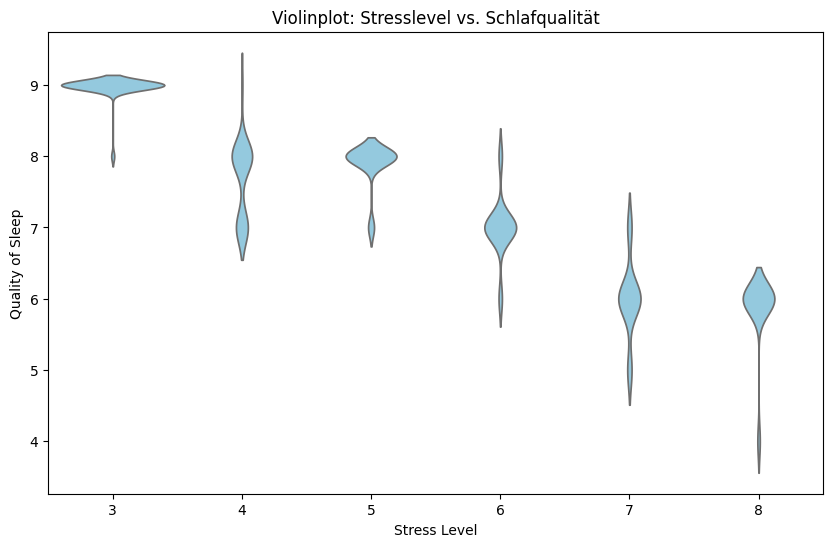

In [14]:
plt.figure(figsize=(10, 6))

# Violin Plot
sns.violinplot(data=df_cleaned, x='Stress Level', y='Quality of Sleep', inner=None, color="skyblue")

plt.title('Violinplot: Stresslevel vs. Schlafqualität')
plt.show()

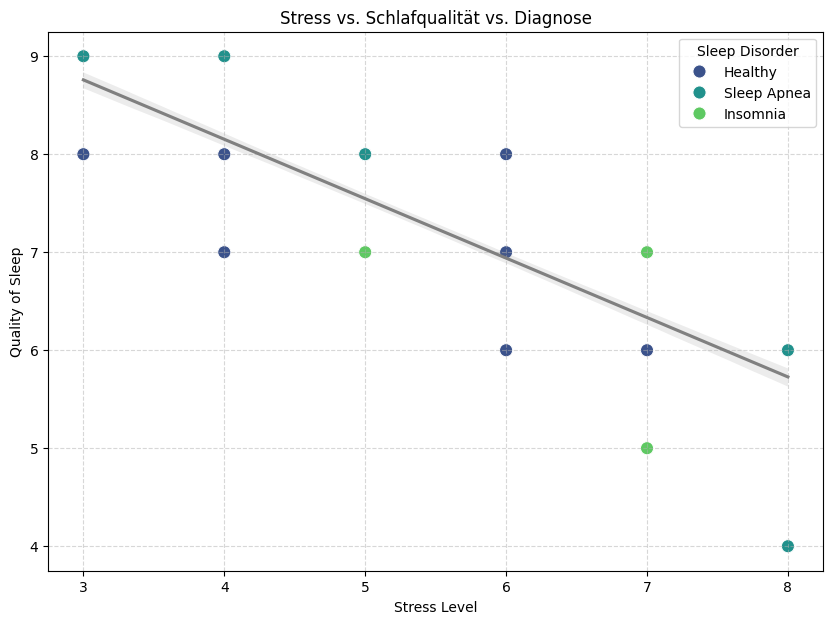

In [15]:
plt.figure(figsize=(10, 7))


sns.scatterplot(data=df_cleaned, x='Stress Level', y='Quality of Sleep', 
                hue='Sleep Disorder', palette='viridis', s=90)


sns.regplot(data=df_cleaned, x='Stress Level', y='Quality of Sleep', 
            scatter=False, color='gray')

plt.title('Stress vs. Schlafqualität vs. Diagnose')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Das Diagramm zeigt nochmal eindeutig den Zusammenhang zwischen Schlafqualität und Stress, aber dir zufällige Verteilung der Punktfarben (Schlafstörungen) zeigt, dass man daraus nicht direkt eine Diagnose ableiten kann

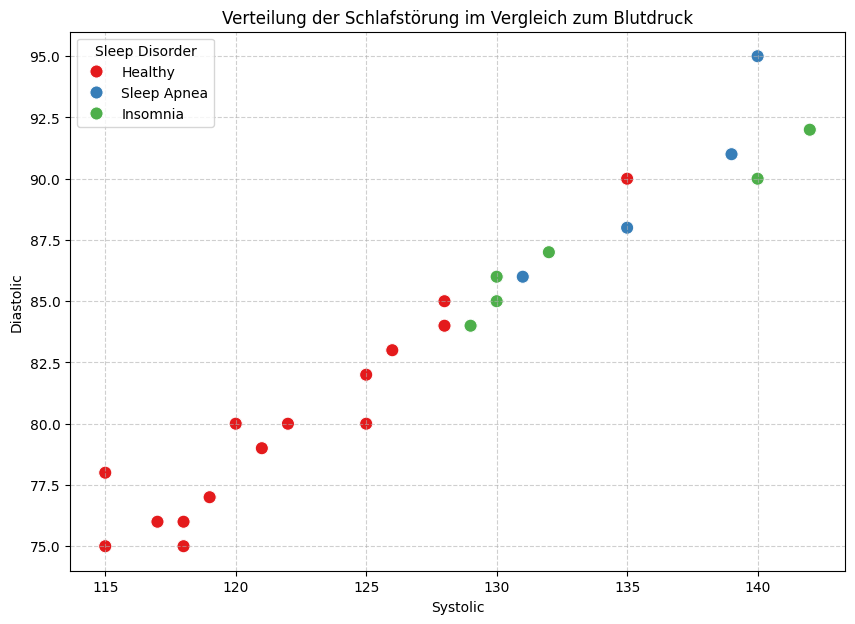

In [16]:
plt.figure(figsize=(10, 7))

# Die Farbe (hue) zeigt die Diagnose
sns.scatterplot(data=df_cleaned, x='Systolic', y='Diastolic', 
                hue='Sleep Disorder', palette='Set1', s=90)

plt.title('Verteilung der Schlafstörung im Vergleich zum Blutdruck')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Dieses Diagramm zeigt, dass ein erhöhterr Blutdruck stark mit Schlafstörungen zusammenhängt, während sich die gesunden Personen in diesem Datensatz fast aussschließlich im unteren linken viertel befinden.

## 4. Train/-Test-Split & Encoding

Bevor das Modell trainiert wird, muss der Datensatz gesplittet werden, damit die Daten mit denen getestet wird das Training nicht beeinflussen.

In [17]:
X = df_cleaned.drop(columns=["Sleep Disorder"])

y = df_cleaned["Sleep Disorder"]

X.shape, y.head()


((374, 13),
 0        Healthy
 1        Healthy
 2        Healthy
 3    Sleep Apnea
 4    Sleep Apnea
 Name: Sleep Disorder, dtype: str)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=28, test_size=0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((299, 13), (299,), (75, 13), (75,))

#### Label encoding für Zielvariable

In [ ]:
target_mapping = {'Healthy': 0, 'Insomnia': 1, 'Sleep Apnea': 2}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)

#### Binäry encoding für Binäre Features (Gender)

In [20]:
X_train['Gender'] = X_train['Gender'].map({'Male': 0, 'Female': 1})
X_test['Gender'] = X_test['Gender'].map({'Male': 0, 'Female': 1})
X_train.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic
26,27,0,30,Doctor,7.8,7,75,6,Normal,70,8000,120,80
28,29,0,30,Doctor,7.9,7,75,6,Normal,70,8000,120,80
328,329,1,53,Engineer,8.3,9,30,3,Normal,65,5000,125,80
270,271,1,49,Nurse,6.1,6,90,8,Overweight,75,10000,140,95
350,351,1,57,Nurse,8.1,9,75,3,Overweight,68,7000,140,95


#### One-Hot Encoding für die Kategorialen Features (Occupation, BMI Category)

In [21]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")

Encoder auf Trainingsdaten anwenden:

In [22]:
transformed_train_data = encoder.fit_transform(X_train[["Occupation", "BMI Category"]])

transformed_train_data.head()

,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight
26,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
328,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
270,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
350,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Und auf die Testdaten:

(Wichtig: encoder.transform, nicht encoder.fit_transform, da der fit bereits auf dem Trainingsdaten gemacht wurde)

In [41]:
transformed_test_data = encoder.transform(X_test[["Occupation", "BMI Category"]])
transformed_test_data.head()

,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight
178,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
332,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
295,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
49,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Die Datensätze jeweils zu einem finalen Datensatz zusammenfassen:

In [24]:
X_train_final = pd.concat([X_train.drop(columns=["Occupation", "BMI Category"]), transformed_train_data], axis=1)

X_test_final = pd.concat([X_test.drop(columns=["Occupation", "BMI Category"]), transformed_test_data], axis=1)
X_test_final.head()

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight
178,179,0,42,7.8,8,90,5,70,8000,130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
332,333,1,54,8.4,9,30,3,65,5000,125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300,301,1,51,8.5,9,30,3,65,5000,125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
295,296,1,50,6.0,6,90,8,75,10000,140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
49,50,0,31,7.7,7,75,6,70,8000,120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Feature Engineering & Feature Selection

Aus den beiden verschiedenen aber dennoch eng miteinander verbundenen Features "Quality of Sleep" und "Sleep Duartion" lässt sich ein Schlafindex berechnen, der beide Features vereint. Für diesen gilt:
$$
\text{Sleepindex} = \frac{\text{Quality of Sleep}}{\text{Sleep Duaration}}
$$

Ein hoher Wert bedeutet kurzer aber erholsamer Schlaf und ein niedriger Wert bedeutet langer aber wenig erholsamer Schlaf.

In [25]:
X_train_final['Sleep Index'] = (X_train_final['Quality of Sleep'] / X_train_final['Sleep Duration']).round(2)
X_test_final['Sleep Index'] = (X_test_final['Quality of Sleep'] / X_test_final['Sleep Duration']).round(2)

X_train_final.head()

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,Sleep Index
26,27,0,30,7.8,7,75,6,70,8000,120,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.90
28,29,0,30,7.9,7,75,6,70,8000,120,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.89
328,329,1,53,8.3,9,30,3,65,5000,125,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.08
270,271,1,49,6.1,6,90,8,75,10000,140,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.98
350,351,1,57,8.1,9,75,3,68,7000,140,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.11


Im nächsten Schritt sollen alle Features, die keinen oder kaum Informationen liefern oder das Modell verwirren könnten, entfernt werden.

Folgende Features werden entfernt:
- Person ID: bringt keine Informationen in Bezug auf eine Schlafstörung
- Sleep Duration & Quality of Sleep: wurde durch den Schlafindex ersetzt
- Daily Steps: sehr ähnlich zu "Physical Activity Level" -> hohe Korrelation (siehe Korrelationsmatrix)
- Diastolic: korreliert hochgradig mit Systolic, deshalb kann dieses Feature weggelassen werden

In [26]:
X_train_final = X_train_final.drop(columns=["Person ID", "Sleep Duration", "Quality of Sleep", "Daily Steps", "Diastolic"])

X_train_final.head()

,Gender,Age,Physical Activity Level,Stress Level,Heart Rate,Systolic,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,Sleep Index
26,0,30,75,6,70,120,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.90
28,0,30,75,6,70,120,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.89
328,1,53,30,3,65,125,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.08
270,1,49,90,8,75,140,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.98
350,1,57,75,3,68,140,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.11


In [27]:
X_test_final = X_test_final.drop(columns=["Person ID", "Sleep Duration", "Quality of Sleep", "Daily Steps", "Diastolic"])

X_test_final.head()

,Gender,Age,Physical Activity Level,Stress Level,Heart Rate,Systolic,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,Sleep Index
178,0,42,90,5,70,130,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.03
332,1,54,30,3,65,125,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.07
300,1,51,30,3,65,125,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.06
295,1,50,90,8,75,140,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00
49,0,31,75,6,70,120,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.91


## 6. Modelierung

Für die Vorhersage wird ein Random Forest trainiert. 
Dieser ist für Klassifikation gut geeiget, robust und benötigt keine Skalierung.

In [28]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=11)

random_forest_model.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
prediction = random_forest_model.predict(X_test_final)

## 7. Auswertung

In [30]:
acc = accuracy_score(y_test, prediction)
prec = precision_score(y_test, prediction, average='weighted')
rec = recall_score(y_test, prediction, average='weighted')
f1 = f1_score(y_test, prediction, average='weighted')
f1_macro = f1_score(y_test, prediction, average='macro')

print(f"Accuracy:  {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1-Score:  {f1:.2%}")
print(f"F1-Score Macro:  {f1_macro:.2%}")

Accuracy:  89.33%
Precision: 90.03%
Recall:    89.33%
F1-Score:  89.29%
F1-Score Macro:  88.62%


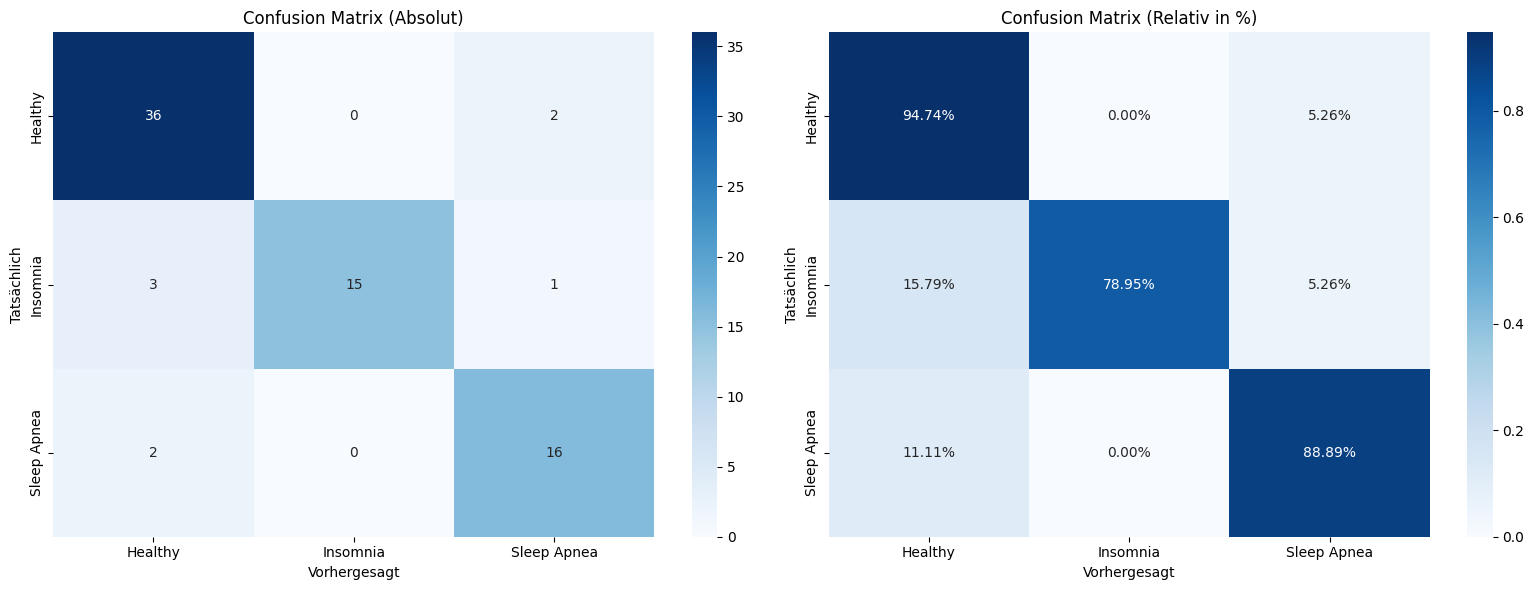

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
conf_matrix = confusion_matrix(y_test, prediction)

confusion_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# absolute Zahlen
sns.heatmap(conf_matrix, ax=axes[0], annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_mapping.keys(), 
            yticklabels=target_mapping.keys())
axes[0].set_title('Confusion Matrix (Absolut)')
axes[0].set_xlabel('Vorhergesagt')
axes[0].set_ylabel('Tatsächlich')

# relative Zahlen
sns.heatmap(confusion_matrix_percent, ax=axes[1], annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=target_mapping.keys(),
            yticklabels=target_mapping.keys())
axes[1].set_title('Confusion Matrix (Relativ in %)')
axes[1].set_xlabel('Vorhergesagt')
axes[1].set_ylabel('Tatsächlich')

plt.tight_layout()
plt.show()

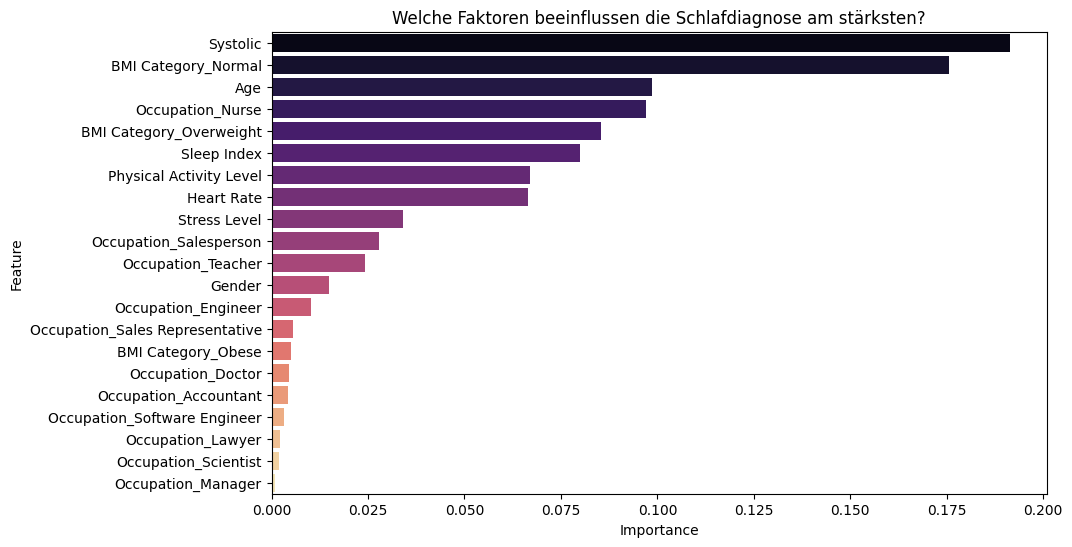

In [42]:
# Rangliste der Wichtigkeit erstellen
importances = random_forest_model.feature_importances_
feature_names = X_train_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue="Feature")
plt.title('Welche Faktoren beeinflussen die Schlafdiagnose am stärksten?')
plt.show()